# Часть 1: знакомство с данными

Подключите gpu в kaggle/google colab

## Данные датасета

In [6]:
# Установите необходимые библиотеки

!pip install pymorphy3

In [7]:
import pandas as pd
import seaborn as sns
import wordcloud
import nltk
import re
import torch
import pymorphy3
from nltk.corpus import stopwords
from collections import Counter
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

Выводим информацию о датасете

In [8]:
# Путь к датасету
df = pd.read_csv("/kaggle/input/datasets/.../.../data.csv")

In [9]:
df.head()

,query_text
0,гетры y2k черные широкие
1,шторы в спальню 100*210
2,big bcaa
3,щетки на болгарку диолд
4,цинк и медь хелат


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   query_text  20000 non-null  object
dtypes: object(1)
memory usage: 156.4+ KB


In [11]:
df.describe()

,query_text
count,20000
unique,20000
top,обруч конфетка
freq,1


In [12]:
print(f"Количество уникальных запросов: {len(df["query_text"].unique())}")

Количество уникальных запросов: 20000


## Количественные характеристики запросов

Строим распределения количеств слов и символов в запросах

Среднее количество слов - 3.89935
Среднее количество символов в запросе - 25.56565


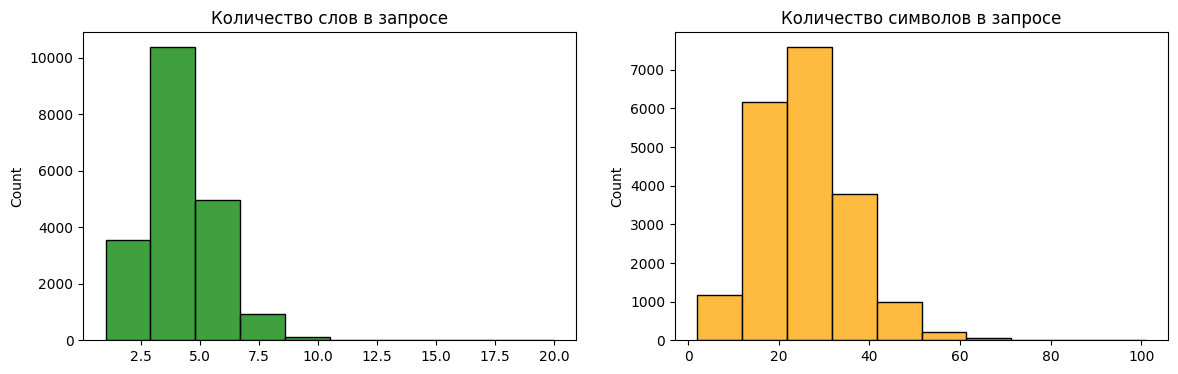

In [13]:
def visualize_stats(data):
    """
    Считаем среднее количество слов и символов в запросе, а также визуализируем эти данные с помощью гистограмм.
    """
    words_lst = list(data)
    cnt_words = [len(i.split()) for i in words_lst]
    n_symb = [len(i) for i in words_lst]

    print(f"Среднее количество слов - {sum(cnt_words) / len(cnt_words)}")
    print(f"Среднее количество символов в запросе - {sum(n_symb) / len(n_symb)}", end="\n")

    fig, ax = plt.subplots(figsize=(14, 4), ncols=2, nrows=1)
    ax[0].set_title("Количество слов в запросе")
    ax[1].set_title("Количество символов в запросе")
    sns.histplot(cnt_words, bins=10, color='green', ax=ax[0])
    sns.histplot(n_symb, bins=10, color='orange', ax=ax[1])


visualize_stats(df["query_text"])


Чаще всего встречаются вопросы с 4 словами и длиной около 25 символов. В среднем запросы очень короткие и состоят из нескольких слов. Особенность текстов запросов в том, что они написаны "рваным" языком. Полные слова часто сокращаются, и некоторые части речи пропускаются для простоты. 

## Облако слов

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


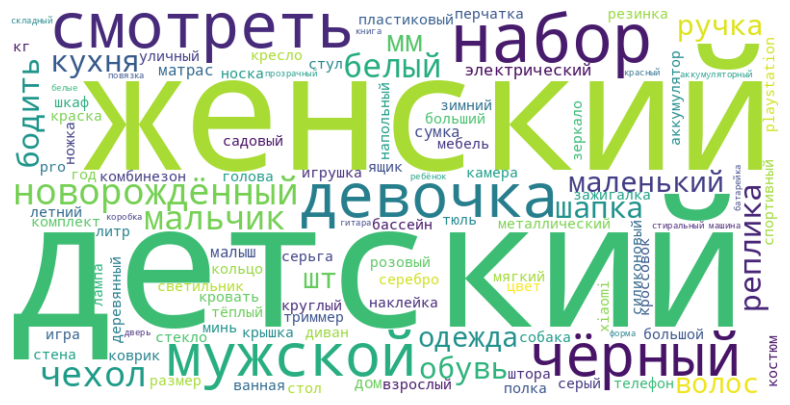

In [14]:
nltk.download('stopwords')
russian_stopwords = set(stopwords.words('russian'))

def create_worcloud(data):
    """
    Создаем облако слов для визуализации наиболее часто встречающихся слов в запросах.
    Используется лемматизация, а также удаление стоп-слов и пунктуации.
    """
    morph = pymorphy3.MorphAnalyzer(lang="ru")

    def preprocess(word):
        parsed = morph.parse(word)[0]
        return parsed.normal_form

    words_lst = list(data)
    words_lst = [i.split() for i in words_lst]
    words_lst = [i for s in words_lst for i in s]
    txt = " ".join(words_lst).lower()
    cleaned_txt = re.sub(r'[^\w\s]', '', txt)

    lemmatized = " ".join([preprocess(word) for word in cleaned_txt.split()])

    cloud = wordcloud.WordCloud(width=800, height=400, background_color='white', stopwords=russian_stopwords, max_words=110).generate(lemmatized)

    plt.figure(figsize=(10, 5))
    plt.imshow(cloud, interpolation='bilinear')
    plt.axis('off')
    plt.show()

create_worcloud(df["query_text"])

Важные закономерности и атрибуты

- В запросах преобладают товары для дома (категории 'мебель', 'одежда и обувь' и др.)

- Часто встречаются атрибуты товаров, связанные с возрастом/полом ('мальчик', 'девочка', 'женский' и т.д.)

- Покупатели часто ищут товары комплектами (встречаются слова 'набор', 'комплект')

- Среди атрибутов товаров чаще всего встречаются материалы (деревянный, металлический), вес и размер ('кг', 'мм'), количество (шт), цвета, предназначение ('садовый', 'детский' и др.)

## Анализ биграмм

In [15]:
def extract_ngrams(text, n=2):
    """
    Ивзлекаем n-граммы из очищенного текста
    """
    words = re.findall(r'[а-яёa-z]+', text.lower())
    return [' '.join(words[i:i+n]) for i in range(len(words)-n+1)]

# Извлекаем биграммы из всех запросов и находим 100 самых частых биграмм
all_bigrams = []
for query in df['query_text']:
    all_bigrams.extend(extract_ngrams(query, n=2))

top_bigrams = Counter(all_bigrams).most_common(100)

def cluster_by_bigram(query, anchor_bigrams, n):
    """
    Присваиваем анализируемому запросу кластер биграммы, если он содержит эту биграмму, иначе - 'other'
    """
    query_bigrams = set(extract_ngrams(query, n=n))
    for bigram, _ in anchor_bigrams:
        if bigram in query_bigrams:
            return bigram
    return 'other'

# Создаем новый столбец под признак
df['bigram_cluster'] = df['query_text'].apply(lambda x: cluster_by_bigram(x, top_bigrams, 2))

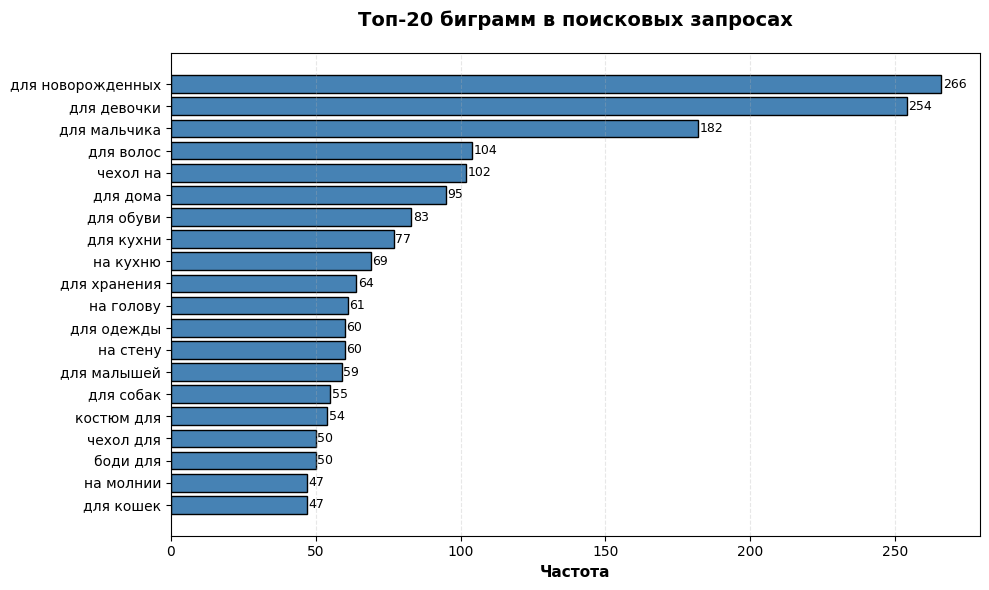

In [16]:
def visualize_bigram_clusters(top_bigrams):
    """
    Визуализируем топ-20 биграмм
    """
    bigrams, counts = zip(*top_bigrams[:20])
    labels = [f"{bg}" for bg in bigrams]

    # Используем горизонтальную гистограмму
    plt.figure(figsize=(10, 6))
    bars = plt.barh(range(len(labels)), counts, color='steelblue', edgecolor='black')

    # Добавляем подписи с количеством запросов для каждой биграммы
    for bar, count in zip(bars, counts):
        plt.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, str(count), va='center', fontsize=9)

    # Настраиваем оси и заголовок
    plt.yticks(range(len(labels)), labels, fontsize=10, ha='right')
    plt.xlabel('Частота', fontsize=11, fontweight='bold')
    plt.title('Топ-20 биграмм в поисковых запросах', fontsize=14, fontweight='bold', pad=20)
    plt.gca().invert_yaxis()
    plt.grid(axis='x', alpha=0.3, linestyle='--')
    plt.tight_layout()
    plt.show()

visualize_bigram_clusters(top_bigrams)

Анализ биграмм показал, что чаще всего в запросах встречаются детские товары и товары для новорожденных, после них по частоте идут товары для дома, ухода за собой и запросы, связанные с одеждой. Биграммы, на мой взгляд, можно с достаточно высокой точностью использовать для кластеризации. Очевидно, что такие биграммы, как "товары для кошек", "товары для собак" относятся к общей категории "товары для животных", а биграммы "костюм для", "для одежды" относятся к одежде. Таким образом, биграммы позволяют определить общую категорию запроса без обращения к языковым моделям, определяющим семантику. Неоднозначные кластеры, такие как "для волос" можно отсмотреть вручную. Вполне вероятно, что биграмма указывает на такие категории, как "шампуни" или "расчески".

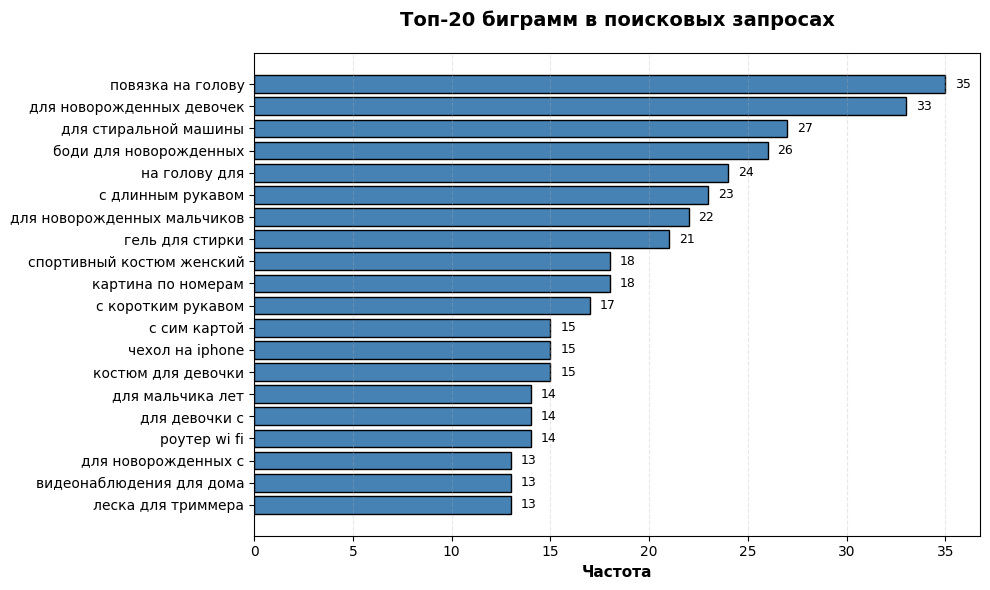

In [17]:
# Анализируем триграммы
all_trigrams = []
for query in df['query_text']:
    all_trigrams.extend(extract_ngrams(query, n=3))

top_trigrams = Counter(all_trigrams).most_common(100)
df['trigram_cluster'] = df['query_text'].apply(lambda x: cluster_by_bigram(x, top_trigrams, 3))
visualize_bigram_clusters(top_trigrams)

Анализ триграмм указывает на конкретные популярные товары, но менее информативен, чем анализ биграмм.

# Часть 2. Извлечение атрибутов (Rule-based)

## Rule-based пайплайн (регулярки + словари + ML)

Решение использует комбинацию регулярных выражений, словарей и методов ML.


В пайплайне определяем следующие признаки:

- Тип товара
- Бренд/модель
- Цвет товара
- Мера (числовая характеристика меры)
- Прилагательные (описание товара)
- Пол и возрастная категория
- Сезон
- Кластеры биграмм и триграмм
- Название меры (мм, см и т.д.)
- Категория меры (длина, объем, количество и т.д.)

Обоснование выбора инструментов:

- Сущности "Цвет", "Пол и возрастная категория", "Мера", "Сезон" достаточно надежно ловятся при помощи словарей и регулярок. Эти сущности содержат достаточно ограниченный список значений, поэтому считаю приемлемым использовать детерменированные методы (по крайней мере для прототипа).

- Сущности "Кластер биграммы" и "Кластер" также представляют собой ценную информацию, которая извлекается без использования ML на основе частотного анализа.

- Сущность "прилагательное" несет ценную описательную информацию и легко ловится при помощи морфологического анализа.

- Сущности "Бренд/модель" и "Тип товара" имеют огромные словари значений, поэтому для их детекции можно использовать ML-методы.

- Для проверки результатов определения бренда и типа товара используется модуль-валидатор на базе rubert-tiny2. Она позволяет исключать из выдачи слова, не являющиеся с высокой достоверностью названиями брендов и категорий товаров (подробнее о модели - в блоке анализа результатов). 

- Название меры и категория меры неплохо извлекаются и без ML, для продакшн-решения можно будет собрать самые частые меры по данным маркетплейса.

- Для продакшна можно расширить словари, заменить некоторые словари на NER-модели, строить ансамбли моделей и реализовать более комплексную логику извлечения и валидации атрибутов

Важно:

- Для извлечения сущностей и брендов использовалась опенсорсная модель. По мере накопления размеченных данных можно обучить свою.

- Пайплайн не является полноценным продакшн-решением, так как на его разработку потребовалось бы больше времени и наличие размеченных датасетов. Решение открыто для доработок и дальнейшего развития.

- Ниже предоставлено одно из возможных решений


In [18]:
# Опенсорсная модель для определения бренда и типа товара (можно заменить на свою, обучив на качественно размеченном датасете)
from transformers import pipeline

# Создаем пайплайн классификации
model_id = "Martsv07/rubert-ner-search-queries"

ner_pipeline = pipeline(
    "token-classification",
    model=model_id,
    tokenizer=model_id,
    aggregation_strategy="simple",
)


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/709M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

In [19]:
# Подключаем tqdm для пандас
tqdm.pandas()

In [20]:
import torch
import numpy as np
from tqdm.auto import tqdm
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# Загружаем заранее обученную модель-валидатор (подробные данные о модели - в блоке "Подробнее о дообученной модели")
repo = "VBadazhkov/category_detector"
tokenizer = AutoTokenizer.from_pretrained(repo)
model = AutoModelForSequenceClassification.from_pretrained(repo)

# Переврдим в режим инференса и кладем на gpu
model.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Тест кейсы для валидатора
queries = [
    "кроссовки nike белые",
    "просто стол деревянный",
    "чехол на iphone 15",
    "adidas"
]

# Получаем предсказание валидатора (функция для обработки отдельных запросов, не батчами)
def get_validator_pred(q):
    inputs = tokenizer(q, return_tensors="pt", truncation=True, padding=True, max_length=128).to(device)
    with torch.no_grad():
        logits = model(**inputs).logits
        probs = torch.sigmoid(logits)[0]
        brand_pred = "есть бренд" if probs[0] > 0.7 else "нет бренда"
        category_pred = "есть категория" if probs[1] > 0.5 else "нет категории"
    return brand_pred, category_pred

for i in queries:
    print(f"Запрос: {i}", f"Ответ модели: {get_validator_pred(i)}", sep="\n")

config.json:   0%|          | 0.00/832 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/376 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/117M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/57 [00:00<?, ?it/s]

Запрос: кроссовки nike белые
Ответ модели: ('есть бренд', 'есть категория')
Запрос: просто стол деревянный
Ответ модели: ('нет бренда', 'есть категория')
Запрос: чехол на iphone 15
Ответ модели: ('нет бренда', 'есть категория')
Запрос: adidas
Ответ модели: ('есть бренд', 'нет категории')


In [21]:
def get_validator_preds_batch(texts, batch_size=64):
    """
    Батчевая версия валидатора.
    Возвращает два списка: предсказания по брендам и по категориям.
    """
    all_brand_preds = []
    all_cat_preds = []
    
    # Используем tqdm для отслеживания прогресса
    for i in tqdm(range(0, len(texts), batch_size)):
        batch_texts = texts[i:i+batch_size]
        inputs = tokenizer(
            batch_texts, 
            return_tensors="pt", 
            truncation=True, 
            padding=True, 
            max_length=128
        ).to(device)
        
        with torch.no_grad():
            logits = model(**inputs).logits
            probs = torch.sigmoid(logits)
            
        # Обрабатываем пороги
        brand_preds = ["нет бренда" if p[0] <= 0.8 else "есть бренд" for p in probs.cpu().numpy()]
        cat_preds = ["нет категории" if p[1] <= 0.5 else "есть категория" for p in probs.cpu().numpy()]
        
        all_brand_preds.extend(brand_preds)
        all_cat_preds.extend(cat_preds)
        
    return all_brand_preds, all_cat_preds

Инференс около 2 минут на T4, подключите gpu в google colab/kaggle

In [22]:
# Инициализация морфологического анализатора
morph = pymorphy3.MorphAnalyzer(lang='ru')

# Словари для поиска брендов (можно расширить)
BRANDS_DICT = {
    'samsung', 'apple', 'xiaomi', 'huawei', 'honor', 'oppo', 'vivo', 'realme', 'oneplus',
    'sony', 'lg', 'asus', 'lenovo', 'hp', 'dell', 'acer', 'msi', 'razer', 'logitech',
    'canon', 'epson', 'brother', 'kyocera', 'xerox', 'panasonic', 'philips', 'braun',
    'bosch', 'siemens', 'electrolux', 'indesit', 'ariston', 'beko', 'haier', 'gorenje',
    'karcher', 'thomas', 'dyson', 'irobot', 'polaris', 'redmond', 'kitfort', 'moulinex',
    'tefal', 'scarlett', 'vitek', 'supra', 'dex', 'bbk', 'dexp', 'harper', 'hi',
    'nike', 'adidas', 'puma', 'reebok', 'new balance', 'asics', 'under armour', 'skechers',
    'converse', 'vans', 'timberland', 'dr. martens', 'ecco', 'geox', 'ralf ringer', 'tommee tippee',
    'zara', 'h&m', 'uniqlo', 'gap', 'levis', 'wrangler', 'lee', 'calvin klein', 'tommy hilfiger',
    'lacoste', 'fred perry', 'benetton', 'colin\'s', 'befree', 'sela', 'love republic', 'gloss',
    'makita', 'bosch', 'metabo', 'hitachi', 'dewalt', 'stanley', 'black&decker', 'ryobi',
    'diold','toyota', 'volkswagen', 'bmw', 'mercedes', 'audi', 'ford', 'kia', 'hyundai', 'lada',
    'lego', 'barbie', 'hot wheels', 'mattel', 'hasbro', 'playmobil', 'schleich',
    'ikea', 'hoff', 'leroy merlin', 'obi', 'castorama',
    'denver', 'starline', 'sher-khan', 'alligator', 'panasonic', 'jvc', 'kenwood', 'pioneer',
    'nivea', 'loreal', 'garnier', 'schwarzkopf', 'syoss', 'taft', 'got2b', 'clear', 'head & shoulders',
    'gillette', 'braun', 'oral-b', 'remington', 'rowenta', 'babyliss', 'philips', 'moser'
}

# Базовые цвета
COLORS_DICT = {
    "черный", "чёрный", "белый", "серый", "синий", "красный", "зеленый", "зелёный", "розовый", "бежевый", 
    "голубой", "желтый", "коричневый", "фиолетовый", "оранжевый", "бордовый", 
    "золотой", "серебряный", "бирюзовый", "хаки",
    "графит", "антрацит", "марсала", "фуксия", "олива", "оливковый", "неон",
    "персиковый", "коралловый", "лососевый", "малиновый", "алый", "вишневый",
    "темно-синий", "светло-серый", "темно-серый", "пыльная роза", "пудровый",
    "шампань", "медный", "бронзовый", "латунный", "хромированный", "металлик",
    "нюдовый", "телесный", "кремовый", "молочный", "кофейный", "шоколадный",
    "изумрудный", "салатовый", "болотный", "горчичный", "лимонный", "канареечный"
}

# Пол
SEX_DICT = {"мужской", "женский", "унисекс", "male", "female", "unisex", "мужчина", "женщина", "мальчик", "девочка"}

# Стоп-слова для прилагательных, которые не несут полезной информации для извлечения атрибутов.
ADJ_STOP_WORDS = {
    'новый', 'старый', 'хороший', 'плохой', 'лучший', 'разный', 'каждый', 
    'самый', 'такой', 'этот', 'тот', 'всякий', 'любой', 'прочий', 'иной',
    'обычный', 'простой', 'главный', 'первый', 'последний', 'второй', 'третий'
}

# Меры товаров и категории мер (список можно расширить)
MEASURE_NAMES = {
    "мм": "length", "mm": "length", "см": "length", "cm": "length", "м": "length", "meter": "length", "метр": "length", "км": "length", "km": "length", "дюйм": "length", "дюйма": "length", "дюймов": "length", "inch": "length", '"': "length",
    "мл": "volume", "ml": "volume", "л": "volume", "литр": "volume", "литра": "volume", "литров": "volume",
    "мг": "weight", "mg": "weight", "г": "weight", "гр": "weight", "грамм": "weight", "грамма": "weight", "g": "weight", "кг": "weight", "kg": "weight", "lb": "weight", "lbs": "weight", "oz": "weight",
    "м2": "area", "м²": "area", "cm2": "area", "см2": "area",
    "xxs": "clothes_size", "xs": "clothes_size", "s": "clothes_size", "m": "clothes_size", "l": "clothes_size", "xl": "clothes_size", "xxl": "clothes_size", "xxxl": "clothes_size", "4xl": "clothes_size", "5xl": "clothes_size",
    "eur": "shoe_size", "eu": "shoe_size", "rus": "shoe_size", "uk": "shoe_size", "us": "shoe_size",
    "лет": "age", "год": "age", "года": "age", "months": "age", "month": "age", "мес": "age", "г.": "age", "л.": "age", "м.": "age",
    "шт": "count", "штук": "count", "pcs": "count", "pc": "count",
    "вт": "power", "w": "power", "kw": "power", "квт": "power",
    "v": "voltage",
    "гб": "information", "тб": "information", "мб": "information",
    "°c": "temperature", "c": "temperature",
    "гц": "frequency", "hz": "frequency",
    "км/ч": "speed", "mph": "speed",
    "x": "dimensions", "х": "dimensions", "*": "dimensions",
}

# Сезон
SEASONS = {
    "зима", "весна", "лето", "осень"
}

def get_lemmas_and_adjs(text):
    """
    Возвращает список лемм и список прилагательных (лемм).
    """
    if not isinstance(text, str) or pd.isna(text) or text.strip() == "":
        return [], []
    
    words = text.split()
    lemmas = []
    adjectives = []
    
    for word in words:
        # Очистка от пунктуации
        clean_word = re.sub(r'[^\w\s-]', '', word)
        if not clean_word:
            continue
            
        try:
            p = morph.parse(clean_word)[0]
            lemma = p.normal_form.lower()
            lemmas.append(lemma)
            
            # Проверка на прилагательное
            if 'ADJF' in p.tag or 'ADJS' in p.tag:
                # Фильтруем стоп-слова
                if lemma not in ADJ_STOP_WORDS:
                    adjectives.append(lemma)
        except Exception:
            continue
                
    return lemmas, adjectives


def extract_measures(text):
    """
    Извлекает меры и габариты из текста.

    Габариты вида 210x230 добавляются как единый объект
    Обычные числа просто добавляются в measures
    """

    if not isinstance(text, str):
        return []

    text = text.lower()

    found = []

    pattern_dims = re.compile(
        r'(\d+[.,]?\d*)\s*[xх*]\s*(\d+[.,]?\d*)'
    )

    
    occupied_spans = []

    for match in pattern_dims.finditer(text):
        a = match.group(1).replace(',', '.')
        b = match.group(2).replace(',', '.')

        found.append(f"{a}x{b}")
        occupied_spans.append(match.span())

    pattern_number = re.compile(r'\d+[.,]?\d*')

    for match in pattern_number.finditer(text):

        start, end = match.span()

        # Проверка, входит ли число в уже найденный габарит
        inside_dimension = False

        for dim_start, dim_end in occupied_spans:
            if start >= dim_start and end <= dim_end:
                inside_dimension = True
                break

        if inside_dimension:
            continue

        number = match.group().replace(',', '.')

        found.append(number)

    return found


# Получаем ответы NER-пайплайна
print("NER-обработка в процессе...")
all_ner_results = ner_pipeline(df['query_text'].tolist(), batch_size=64)
df['ner_raw'] = all_ner_results

print("Обработка ответов валидатором...")
val_brands, val_cats = get_validator_preds_batch(df['query_text'].tolist(), batch_size=64)
df['val_brand'] = val_brands
df['val_category'] = val_cats


def preprocess_and_extract(row):
    """
    Основная функция извлечения атрибутов.
    Возвращает словари со списками значений.
    Адаптирована для работы с предварительно вычисленными ML-предсказаниями.
    """
    text = row['query_text']
    ner_results = row['ner_raw']
    has_brand = row['val_brand']
    has_category = row['val_category']
    
    if not isinstance(text, str) or pd.isna(text) or text.strip() == "":
        return {
            'lemmas': '', 
            'brand': [], 
            'color': [], 
            'measure': [], 
            'adjectives': [], 
            'sex': [],
            'category': None
        }
    
    # Извлекаем леммы и прилагательные
    lemmas, adjectives = get_lemmas_and_adjs(text)
    lemmas_text = ' '.join(lemmas)
    lower_text = text.lower()
        
    # Извлекаем бренды
    found_brands = []
    for brand in BRANDS_DICT:
        if re.search(r'\b' + re.escape(brand) + r'\b', lower_text):
            found_brands.append(brand)
            
    # Извлекаем цвета
    found_colors = []
    for color in COLORS_DICT:
        if color in lemmas:
            found_colors.append(color)

    # Извлекаем пол
    found_sex = []
    for sex in SEX_DICT:
        if sex in lemmas:
            found_sex.append(sex) 
            
    # Извлекаем меры
    found_measures = extract_measures(text)

    # Извлекаем название меры и категорию
    found_m_names = []
    found_m_category = []
    for k, v in MEASURE_NAMES.items():
        if k in lemmas:
            found_m_names.append(k)
            found_m_category.append(v)

    # Извлекаем сезон
    found_season = ''
    for s in SEASONS:
        if s in lemmas:
            found_season = s

    # Обрабатываем результаты NER
    found_category = None
    for entity in ner_results:
        if entity['score'] >= 0.7:
            if entity['entity_group'] == "BRAND":
                if entity['word'] not in BRANDS_DICT:
                    found_brands.append(entity['word'])
            if entity['entity_group'] == "TYPE":
                p = morph.parse(entity['word'])[0]
                if 'NOUN' in p.tag:
                  found_category = entity['word']

    # Валидация бренда и категории
    if has_brand == "нет бренда":
        found_brands = [i for i in found_brands if i in BRANDS_DICT]

    if has_category == "нет категории":
        found_category = None
    
    return {
        'lemmas': lemmas_text,
        'category': found_category,
        'brand': " ".join(found_brands),
        'color': " ".join(found_colors),
        'measure': " ".join(found_measures),
        'adjectives': " ".join(adjectives),
        'sex': " ".join(found_sex),
        'season': found_season,
        'measure_name': " ".join(found_m_names),
        'measure_category': " ".join(found_m_category)
    }

# Извлекаем атрибуты
df['analysis'] = df.progress_apply(preprocess_and_extract, axis=1)

# Создаем отлельные столбцы для каждого атрибута
df['brand'] = df['analysis'].apply(lambda x: x['brand'])
df['color'] = df['analysis'].apply(lambda x: x['color'])
df['measure'] = df['analysis'].apply(lambda x: x['measure'])
df['adjectives'] = df['analysis'].apply(lambda x: x['adjectives'])
df['sex'] = df['analysis'].apply(lambda x: x['sex'])
df['season'] = df['analysis'].apply(lambda x: x['season'])
df['lemmas'] = df['analysis'].apply(lambda x: x['lemmas'])
df['category'] = df['analysis'].apply(lambda x: x['category'])
df['measure_name'] = df['analysis'].apply(lambda x: x['measure_name'])
df['measure_category'] = df['analysis'].apply(lambda x: x['measure_category'])

# Удаляем служебные колонки
df = df.drop(['analysis', 'ner_raw', 'val_brand', 'val_category'], axis=1)

# Cохраняем результат в новый CSV файл
df_name = 'analysis.csv'
df.to_csv(df_name, index=False)
print(f"Результат сохранен в {df_name}")

NER-обработка в процессе...
Обработка ответов валидатором...


  0%|          | 0/313 [00:00<?, ?it/s]

  0%|          | 0/20000 [00:00<?, ?it/s]

Результат сохранен в analysis.csv


# Часть 3. Анализ извлеченных атрибутов

## Выводы

Анализируя полученный датасет, можно понять, что качество разметки не идеальное. ML-модель в пайплайне часто путает бренд с моделью/типом товара, но при этом цвет,пол целевой аудитории и категория товара извлекаются с достаточно хорошим качеством.

Обучение полноценного NER на полученных данных может быть не очень хорошей идеей, так как модель запомнит грязные метки. Если мы не хотим получить очередную модель-бредогенератор, то стоит заняться качественной разметкой имеющегося датасета. Это решит проблему с моделью для распознавания бренда и типа товара. Альтернативным решением могло бы стать использование методов быстрого поиска по большому словарю, например aho-corasick или ретривал-системы для семантического поиска по имеющейся базе брендов.
В силу ограниченности времени и трудоемкости работы я не стал заниматься полноценной разметкой датасета. Опыт также показал, что и llm не всегда хорошо справлялись с разметкой (gpt-4o).

Получение качественно размеченного датасета запросов для обучения NER - это потенциальный путь развития пайплайна тестового задания. Вместо создания NER я обучил BERT модель как валидатор, который можно использовать для повышения надежности обнаружения некоторых атрибутов в пайплайне. Это позволит повысить надежность пайплайна, добавив дополнительный "сигнал" к имеющимся жестко заданным правилам. Модель будет правильно определять наличие бренда, даже если в запросе будут опечатки (samsung и sam sung семантически близки). Естественно, при обучении следуем принципу "garbage in -> garbage out", так что для корректной работы модели на уровне продакшна, опять-таки, потребуется хороший размеченный датасет.

In [23]:
# Датасет результата. Если не все столбцы помещаются, пролистните вправо
df.tail(60)

,query_text,bigram_cluster,trigram_cluster,brand,color,measure,adjectives,sex,season,lemmas,category,measure_name,measure_category
19940,зонт 2 в 1 с вентилятором,other,other,,,2 1,,,,зонт 2 в 1 с вентилятор,зонт,,
19941,тюль плотная в гостиную с узором,в гостиную,other,,,,плотный гостиный,,,тюль плотный в гостиный с узор,тюль,,
19942,катушка зажигания на 172fmm,other,other,,,172,,,,катушка зажигание на 172fmm,зажигания,,
19943,велотуфли шоссейные,other,other,,,,шоссейный,,,велотуфля шоссейный,велотуфли,,
19944,мицубиси лансер 10 дворники,other,other,мицубиси,,10,,,,мицубиси лансер 10 дворник,None,,
19945,geox мужская обувь кеды,other,other,geox,,,мужской,мужской,,geox мужской обувь кед,кеды,,
19946,комбинезон женский утягивающий черный,other,other,,чёрный,,женский чёрный,женский,,комбинезон женский утягивать чёрный,комбинезон,,
19947,ssd amd 240,other,other,,,240,,,,ssd amd 240,None,,
19948,шнурки хоккейные фиолетовые,other,other,,фиолетовый,,хоккейный фиолетовый,,,шнурок хоккейный фиолетовый,шнурки,,
19949,авео т300,other,other,,,300,,,,авео т300,None,,


## Проблемы пайплайна и пути их решения
**1) Не всегда корректное определение бренда и типа товара (пропуски категории там где она есть или неправильная идентификация бренда)**
   
Решение: расширение базы данных брендов (при необходимости - с поиском через aho-corasick), дообучение NER-модели на качественном размеченном датасете или же ретривал-пайплайн семантического поиска по индексной базе брендов. Потенциально можно добавить харакетристики "материал" и "страна/локация", которые будет определять NER.

**2) Не всегда распознаются редкие категории мер**

Решение: расширение словарей/обучение NER моделей для извлечения меры.

**3) Сложности с классификацией коротких малоинформативных и неоднозначных запросов**
   
Решение: внедрение retrieval-системы, использующую контекст запроса. Позволит отличить вилку питбайка от столовой вилки.


## Пути оптимизации

- Можно ввести поиск по различным словарям в зависимости от категории товара (не нужно пытаться искать сезон для мебели и пол для строительных материалов).

- Оптимизация работы NER (например, конвертация в ONNX для ускорения инференса).

- Правильный подбор модели в пайплайне в зависимости от задачи. Не стоит использовать llm для валидации наличия бренда в запросе, лучше поручить это хорошо дообученным специализированным моделям или словарям/regex, если признак имеет ограниченное множество значений.

- Собирать обратную связь от пользователей и новые данные для улучшения моделей

## Противоречивые примеры

Примеры проблемных запросов.

- Не всегда верно определяются бренд и категория. Иногда категория может отстутствовать, когда она есть. Та же проблема с брендом, иногда в него попадают модели (но для моего прототипа это допустимо, разделение на бренд и модель можно ввести позже)

In [24]:
df.iloc[[19996, 1495, 6778, 9829]]

,query_text,bigram_cluster,trigram_cluster,brand,color,measure,adjectives,sex,season,lemmas,category,measure_name,measure_category
19996,нож финка нквд складной,other,other,финка,,,складный,,,нож финка нквд складный,нож,,
1495,шнек для мясорубки moulinex hv8 2000,other,other,moulinex hv8,,8 2000,,,,шнек для мясорубка moulinex hv8 2000,шнек,,
6778,полка в душевую кабину черная,other,other,,чёрный,,чёрный,,,полка в душевая кабина чёрный,None,,
9829,боди для новорожденных мальчиков 80,для новорожденных,боди для новорожденных,,,80,новорождённый,мальчик,,бодить для новорождённый мальчик 80,None,,


## Подробнее о дообученной модели

Rubert-tiny2, дообученная на предразмеченном датасете брендов и типов товаров, инференсится за милисекунды и не создает большой задержки. В то же время ее размер приемлем для определения наличия признака (категория товара, бренд). Это и стало причиной выбора модели.

Модель создана, чтобы валидировать бренд и тип товара в пайплайне. Если у модели низкий порог уверенности в том, что в запросе присутствует атрибут, она отклоняет реузльтаты извлечения сущностей (если сущности не присутствуют в словарях).

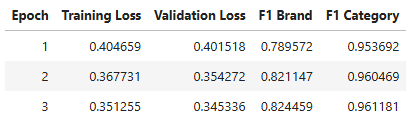